# Laporan Simulasi Model Ising 2D: Fase Feromagnetik

## 1. Pendahuluan dan Landasan Teori
Simulasi ini bertujuan untuk memodelkan fenomena transisi fasa magnetik pada material menggunakan **Model Ising 2 Dimensi**. Sistem direpresentasikan sebagai kisi persegi berukuran $N \times N$, di mana setiap titik kisi memiliki variabel spin $s_i$ yang hanya dapat bernilai $+1$ (spin atas/putih) atau $-1$ (spin bawah/hitam).

Dalam ketiadaan medan magnet eksternal, energi total sistem (Hamiltonian) diatur oleh interaksi energi pertukaran (*exchange energy*) antar-spin yang bertetangga terdekat (*nearest neighbors*), dirumuskan sebagai:

$$H = -J \sum_{\langle i,j \rangle} s_i s_j$$

Di mana:
* $J$ adalah konstanta interaksi pertukaran (asumsi $J > 0$ untuk feromagnetik).
* $\langle i,j \rangle$ menunjukkan penjumlahan hanya dilakukan pada tetangga terdekat.

## 2. Implementasi Algoritma Metropolis (Monte Carlo)
Untuk menyimulasikan dinamika termal sistem, digunakan metode *Markov Chain Monte Carlo* (MCMC) dengan Algoritma Metropolis. Konstanta Boltzmann $k_B$ dan konstanta interaksi $J$ dinormalisasi menjadi 1.

Prosedur implementasinya:
1.  **Pemilihan Spin Acak:** Sebuah titik koordinat $(x, y)$ dipilih secara stokastik dari kisi.
2.  **Perhitungan Perubahan Energi ($\Delta E$):** Dihitung secara efisien menggunakan 4 tetangga terdekatnya (Kondisi Batas Periodik diterapkan menggunakan operator modulo):
    $$\Delta E = 2 s_{i} \sum_{j \in nn} s_j$$
3.  **Kriteria Penerimaan:** * Jika $\Delta E < 0$, pembalikan spin **diterima**.
    * Jika $\Delta E > 0$, probabilitas penerimaan mengikuti **Distribusi Boltzmann** ($P = e^{-\frac{\Delta E}{T}}$).

Memproses simulasi untuk T = 1.0...


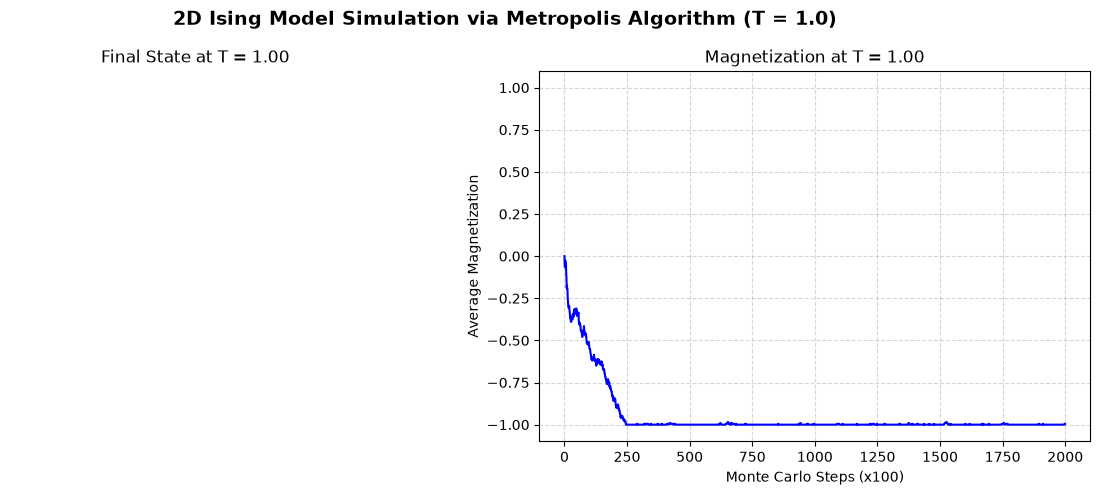

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import random

def metropolis_step(grid, T):
    N = grid.shape[0]
    x, y = random.randint(0, N-1), random.randint(0, N-1)
    
    s_neighbors = (grid[(x+1)%N, y] + grid[(x-1)%N, y] +
                   grid[x, (y+1)%N] + grid[x, (y-1)%N])
    
    delta_E = 2 * grid[x, y] * s_neighbors
    
    if delta_E < 0 or random.random() < np.exp(-delta_E / T):
        grid[x, y] *= -1
        
    return grid

def run_simulation(N=20, temp=1.0, n_steps=100000):
    grid = np.random.choice([-1, 1], size=(N, N))
    magnetization_history = []
    
    for step in range(n_steps):
        grid = metropolis_step(grid, temp)
        
        if step % 100 == 0:
            magnetization = np.mean(grid)
            magnetization_history.append(magnetization)
            
    return grid, magnetization_history

# --- EKSEKUSI KASUS 1 ---
T = 1.0
grid_size = 20
monte_carlo_steps = 200000

print(f"Memproses simulasi untuk T = {T}...")
final_grid, M_history = run_simulation(N=grid_size, temp=T, n_steps=monte_carlo_steps)

# VISUALISASI
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('2D Ising Model Simulation via Metropolis Algorithm (T = 1.0)', fontsize=14, fontweight='bold')

axes[0].imshow(final_grid, cmap='binary', vmin=-1, vmax=1)
axes[0].set_title(f"Final State at T = {T:.2f}")
axes[0].axis('off')

axes[1].plot(M_history, color='blue')
axes[1].set_title(f"Magnetization at T = {T:.2f}")
axes[1].set_xlabel("Monte Carlo Steps (x100)")
axes[1].set_ylabel("Average Magnetization")
axes[1].set_ylim(-1.1, 1.1)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 3. Hasil Simulasi dan Analisis Termodinamika (Kasus 1)

**Kondisi Sistem:** $T = 1.0$ (Suhu Rendah, $T < T_c$)

**Analisis Fisika Statistik:**
Pada suhu $T = 1.0$, energi interaksi pertukaran ($J$) jauh lebih dominan dibandingkan dengan energi agitasi termal ($k_B T$). Kriteria Metropolis akan sangat jarang menerima pembalikan spin yang meningkatkan energi ($\Delta E > 0$). Akibatnya, sistem mengalami fenomena **Perpecahan Simetri Spontan** (*Spontaneous Symmetry Breaking*). 

Spin-spin yang bertetangga cenderung meminimalkan energi Hamiltonian dengan cara menyelaraskan orientasinya secara paralel. Peta visual menunjukkan terbentuknya satu domain magnetik raksasa yang homogen (keseragaman warna). Keteraturan jarak jauh (*long-range order*) terbentuk dengan kokoh, dibuktikan oleh kurva magnetisasi rata-rata yang bergerak asimtotik mendekati nilai mutlak maksimumnya ($|M| \approx 1$). Ini membuktikan karakteristik material paramagnetik yang berubah menjadi feromagnetik secara makroskopis.